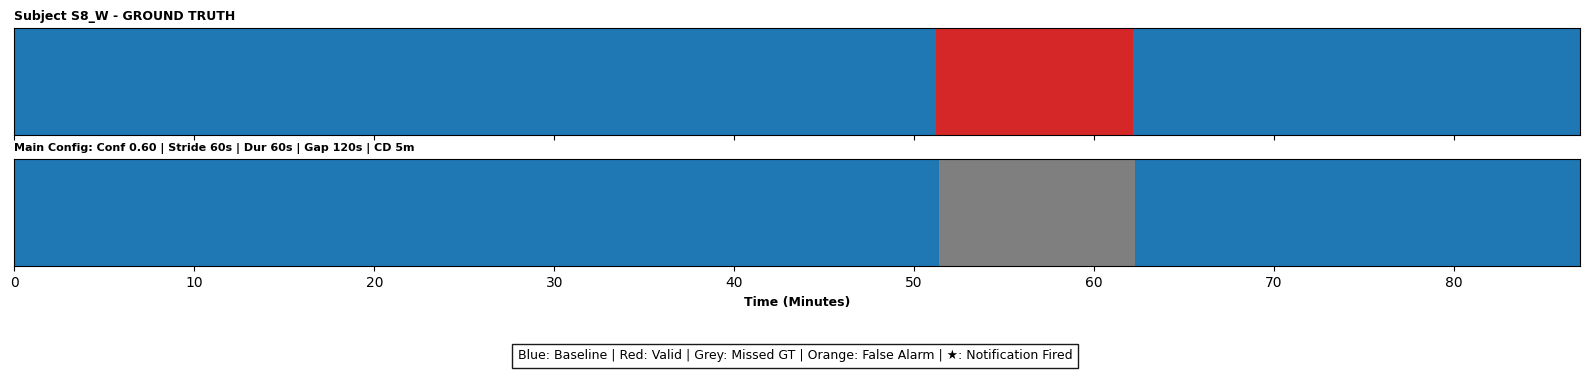

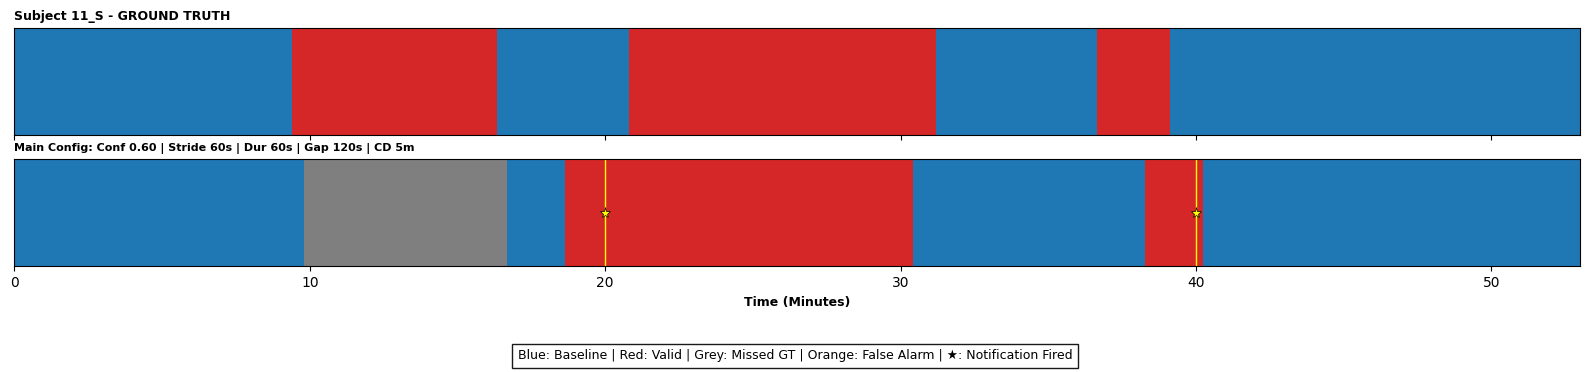

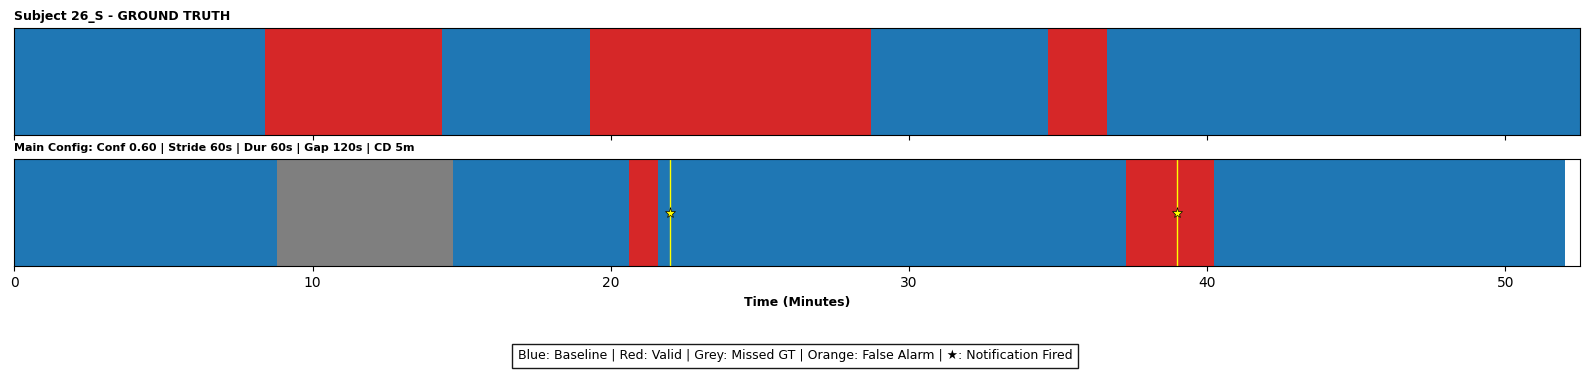

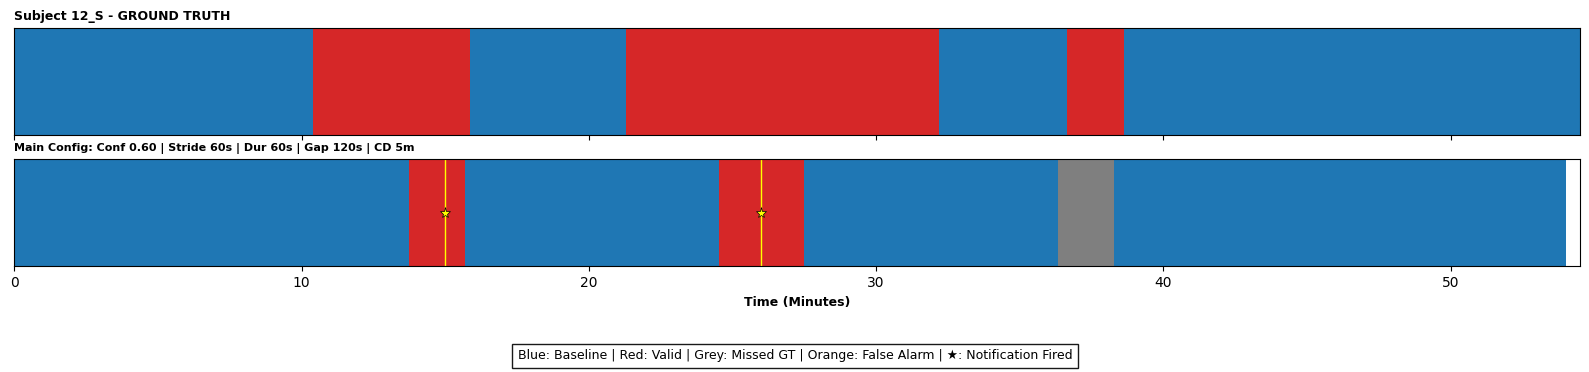

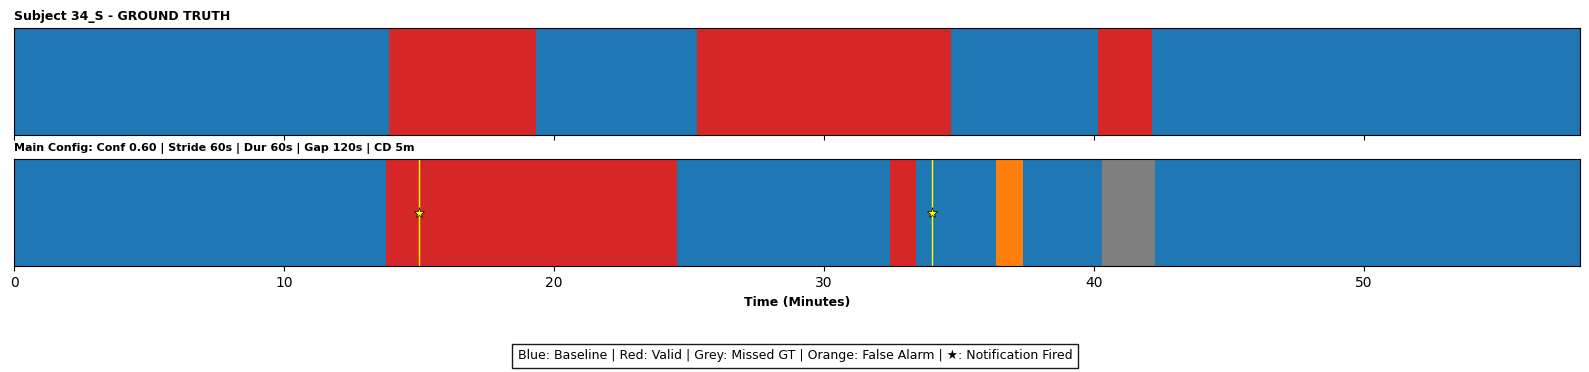

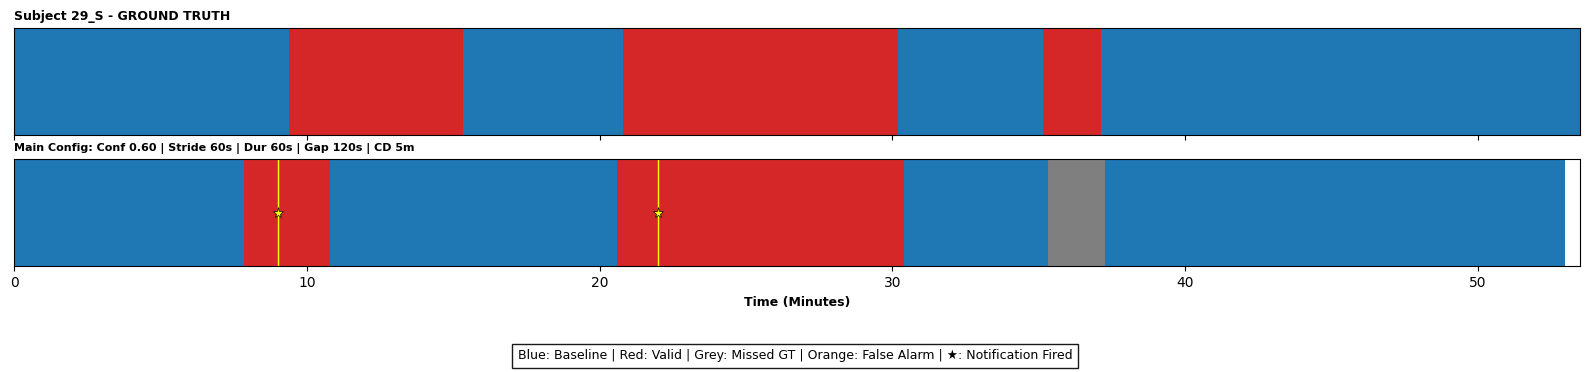

In [2]:
# Final Deployment Visualizer (WESAD w=2.0, MAR 0.1)
# ==========================================
# NOTIFICATION-DRIVEN VISUALIZER (0.1 MAR FILTER, MAIN MODEL ONLY)
# ==========================================
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- DYNAMIC PATH RESOLUTION ---
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
AI_DIR = os.path.dirname(NOTEBOOK_DIR)

SRC_DIR = os.path.join(AI_DIR, 'src')
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)
from mamba_model import create_model

DATA_GALAXY = os.path.join(AI_DIR, 'data', 'galaxy', 'Merged')

# For Cell 1:
CKPT_PATH = os.path.join(AI_DIR, 'checkpoints_final', 'wesad_w2.0', 'deployment_master_weights.pt')


TARGET_SUBS = ['S8_W', '11_S', '26_S', '12_S', '34_S', '29_S']
DEVICE = 'cpu'

# HARDWARE MOTION FILTER
MAR_THRESH = 0.10

# MAIN CONFIG ONLY
CONFIGS = [
    {"name": "Main Config: Conf 0.60 | Stride 60s | Dur 60s | Gap 120s | CD 5m", "stride": 60, "conf": 0.60, "dur": 60, "gap": 120, "cd": 5}
]

GRACE_BEFORE_SEC = 60
GRACE_AFTER_SEC = 120

COLORS = ['#1f77b4', '#d62728', '#7f7f7f', '#ff7f0e'] 
CMAP = ListedColormap(COLORS)

def get_blocks(binary_array):
    padded = np.concatenate(([0], binary_array, [0]))
    diff = np.diff(padded)
    return list(zip(np.where(diff == 1)[0], np.where(diff == -1)[0]))

def apply_ux_filters(preds, min_dur_chunks, max_gap_chunks):
    merged = preds.copy()
    for z_start, z_end in get_blocks(merged == 0):
        if (z_end - z_start) <= max_gap_chunks and z_start > 0 and z_end < len(merged):
            merged[z_start:z_end] = 1
    final_preds = np.zeros_like(merged)
    for p_start, p_end in get_blocks(merged == 1):
        if (p_end - p_start) >= min_dur_chunks:
            final_preds[p_start:p_end] = 1
    return final_preds

def process_visuals(ux_preds, labels, time_minutes, stride_sec, dur_chunks, cd_chunks):
    gt_blocks = get_blocks(labels == 1)
    pred_blocks = get_blocks(ux_preds == 1)
    
    pred_plot = np.zeros_like(ux_preds)
    notifs_idx = []
    last_notified_end_idx = -9999 
    hit_gt_indices = set()
    
    for ps, pe in pred_blocks:
        cooldown_exp = last_notified_end_idx + cd_chunks
        if pe > cooldown_exp:
            trigger_idx = max(ps + dur_chunks, cooldown_exp)
            if trigger_idx <= pe:
                notifs_idx.append(trigger_idx)
            last_notified_end_idx = pe

        is_block_fa = True
        b_s_sec, b_e_sec = ps * stride_sec, pe * stride_sec
        for s_idx, e_idx in gt_blocks:
            valid_start = (s_idx * stride_sec) - GRACE_BEFORE_SEC
            valid_end = (e_idx * stride_sec) + GRACE_AFTER_SEC
            if max(valid_start, b_s_sec) < min(valid_end, b_e_sec):
                is_block_fa = False
                break
        pred_plot[ps:pe] = 3 if is_block_fa else 1

    for n_idx in notifs_idx:
        notif_sec = n_idx * stride_sec
        for i, (s_idx, e_idx) in enumerate(gt_blocks):
            valid_start = (s_idx * stride_sec) - GRACE_BEFORE_SEC
            valid_end = (e_idx * stride_sec) + GRACE_AFTER_SEC
            if valid_start <= notif_sec <= valid_end:
                hit_gt_indices.add(i)
                break
                
    for i, (s_idx, e_idx) in enumerate(gt_blocks):
        if i not in hit_gt_indices:
            pred_plot[s_idx:e_idx] = 2
            
    return pred_plot, notifs_idx

def main():
    X = np.load(os.path.join(DATA_GALAXY, 'Merged_X_binary.npy'))
    y = np.load(os.path.join(DATA_GALAXY, 'Merged_y_binary.npy'))
    sub = np.load(os.path.join(DATA_GALAXY, 'Merged_sub_binary.npy'), allow_pickle=True)

    model_config = {
        'enc_in': X.shape[1], 'seq_len': X.shape[2], 'num_class': 2, 'projected_space': 64, 
        'd_state': 16, 'dconv': 4, 'e_fact': 2, 'num_mambas': 1, 'patch_len': 50, 
        'dropout': 0.3, 'only_forward_scan': 1, 'reverse_flip': 1, 'max_pooling': 0,
    }
    
    model, _ = create_model(model_config)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True).items()}
    model.load_state_dict(state_dict)
    model.to(DEVICE).eval()

    for subject_id in TARGET_SUBS:
        sub_mask = (sub == subject_id)
        if not np.any(sub_mask): continue
            
        fig, axes = plt.subplots(len(CONFIGS) + 1, 1, figsize=(16, 3.5), sharex=True)
        
        y_sub_gt = y[sub_mask].argmax(axis=1)[::6]
        time_minutes_gt = np.arange(len(y_sub_gt)) * 30 / 60.0 
        
        axes[0].imshow(y_sub_gt[None, :], cmap=CMAP, vmin=0, vmax=3, aspect='auto', extent=[time_minutes_gt[0], time_minutes_gt[-1], 0, 1])
        axes[0].set_yticks([])
        axes[0].set_title(f"Subject {subject_id} - GROUND TRUTH", fontweight='bold', loc='left', fontsize=9)
        
        for i, config in enumerate(CONFIGS):
            idx_step = int(config['stride'] / 5)
            X_sub = X[sub_mask][::idx_step]
            y_sub = y[sub_mask].argmax(axis=1)[::idx_step]
            
            sub_acc_mags = np.mean(X_sub[:, 2, :], axis=1) 
            time_minutes = np.arange(len(y_sub)) * config['stride'] / 60.0 
            
            with torch.no_grad():
                probs = F.softmax(model(torch.tensor(X_sub, dtype=torch.float32).to(DEVICE)), dim=1).cpu().numpy()
            
            dur_chunks = max(1, int(round(config['dur'] / config['stride'])))
            gap_chunks = max(1, int(round(config['gap'] / config['stride'])))
            cd_chunks = max(1, int(round((config['cd'] * 60) / config['stride'])))
            
            ux_binary_preds = (probs[:, 1] >= config['conf']).astype(int)
            ux_binary_preds[sub_acc_mags > MAR_THRESH] = 0 # MAR Logic
            
            ux_preds = apply_ux_filters(ux_binary_preds, dur_chunks, gap_chunks)
            plot_res, notifs_idx = process_visuals(ux_preds, y_sub, time_minutes, config['stride'], dur_chunks, cd_chunks)

            ax = axes[i + 1]
            ax.imshow(plot_res[None, :], cmap=CMAP, vmin=0, vmax=3, aspect='auto', extent=[time_minutes[0], time_minutes[-1], 0, 1])
            
            for nt_idx in notifs_idx:
                if nt_idx < len(time_minutes):
                    nt_time = time_minutes[nt_idx]
                    ax.axvline(x=nt_time, color='yellow', linewidth=1.0)
                    ax.plot(nt_time, 0.5, marker='*', markersize=8, color='yellow', markeredgecolor='black', markeredgewidth=0.5)
                
            ax.set_yticks([])
            ax.set_title(config['name'], fontweight='bold', loc='left', fontsize=8)
        
        axes[-1].set_xlabel("Time (Minutes)", fontsize=9, fontweight='bold')
        fig.text(0.5, -0.05, "Blue: Baseline | Red: Valid | Grey: Missed GT | Orange: False Alarm | ★: Notification Fired", ha='center', va='bottom', fontsize=9, bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=4))
        plt.tight_layout(rect=[0, 0.06, 1, 1], h_pad=0.2)
        plt.show()

if __name__ == '__main__':
    main()

In [3]:
# Final Deployment Robustness (WESAD w=2.0, MAR 0.1)
# ==========================================
# NOTIFICATION-DRIVEN PHASE SHIFT ROBUSTNESS (0.1 MAR FILTER, MAIN MODEL ONLY)
# ==========================================
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display, HTML

# --- DYNAMIC PATH RESOLUTION ---
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
AI_DIR = os.path.dirname(NOTEBOOK_DIR)
SRC_DIR = os.path.join(AI_DIR, 'src') 
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)
from mamba_model import create_model

DATA_GALAXY = os.path.join(AI_DIR, 'data', 'galaxy', 'Merged')

# MAIN MODEL ONLY
CHECKPOINTS = {
    "WESAD_Stress (w=2.0)": os.path.join(AI_DIR, 'checkpoints_final', 'wesad_w2.0', 'deployment_master_weights.pt')
}

TARGET_SUBS = ['S8_W', '11_S', '26_S', '12_S', '34_S', '29_S']
DEVICE = 'cpu'

# HARDWARE MOTION FILTER
MAR_THRESH = 0.10

# MAIN CONFIG ONLY
TARGET_CONFIGS = [
    {"model": "WESAD_Stress (w=2.0)", "stride": 60, "conf": 0.60, "gap": 120, "cd": 5}
]

MIN_DUR_SEC = 60                 
GRACE_BEFORE_SEC = 60  
GRACE_AFTER_SEC = 120  
BASE_SHIFT_SEC = 5               

def get_blocks(binary_array):
    padded = np.concatenate(([0], binary_array, [0]))
    diff = np.diff(padded)
    return list(zip(np.where(diff == 1)[0], np.where(diff == -1)[0]))

def apply_ux_filters(preds, min_dur_chunks, max_gap_chunks):
    merged = preds.copy()
    for z_start, z_end in get_blocks(merged == 0):
        if (z_end - z_start) <= max_gap_chunks and z_start > 0 and z_end < len(merged):
            merged[z_start:z_end] = 1
    final_preds = np.zeros_like(merged)
    for p_start, p_end in get_blocks(merged == 1):
        if (p_end - p_start) >= min_dur_chunks:
            final_preds[p_start:p_end] = 1
    return final_preds

def count_events_by_notification(final_preds, labels, grace_before_sec, grace_after_sec, cd_chunks, min_dur_chunks, stride_sec):
    gt_blocks = get_blocks(labels == 1)
    pred_blocks = get_blocks(final_preds == 1)
    
    notifications = []
    last_notified_end_idx = -9999
    
    for ps, pe in pred_blocks:
        cooldown_exp = last_notified_end_idx + cd_chunks
        if pe > cooldown_exp:
            trigger_idx = max(ps + min_dur_chunks, cooldown_exp)
            if trigger_idx <= pe:
                notifications.append(trigger_idx)
            last_notified_end_idx = pe
            
    hit_gt_indices = set()
    false_alarms = 0
    
    for notif_idx in notifications:
        notif_sec = notif_idx * stride_sec
        is_fa = True
        for i, (s_idx, e_idx) in enumerate(gt_blocks):
            valid_start = (s_idx * stride_sec) - grace_before_sec
            valid_end = (e_idx * stride_sec) + grace_after_sec
            if valid_start <= notif_sec <= valid_end:
                if i in hit_gt_indices:
                    is_fa = True 
                else:
                    is_fa = False
                    hit_gt_indices.add(i)
                break
        if is_fa: false_alarms += 1
            
    return len(hit_gt_indices), len(gt_blocks) - len(hit_gt_indices), false_alarms

def evaluate_robustness_asym():
    X = np.load(os.path.join(DATA_GALAXY, 'Merged_X_binary.npy'))
    y = np.load(os.path.join(DATA_GALAXY, 'Merged_y_binary.npy'))
    sub = np.load(os.path.join(DATA_GALAXY, 'Merged_sub_binary.npy'), allow_pickle=True)

    results = []
    model_config = {
        'enc_in': X.shape[1], 'seq_len': X.shape[2], 'num_class': 2, 'projected_space': 64, 
        'd_state': 16, 'dconv': 4, 'e_fact': 2, 'num_mambas': 1, 'patch_len': 50, 
        'dropout': 0.3, 'only_forward_scan': 1, 'reverse_flip': 1, 'max_pooling': 0,
    }

    loaded_models = {}
    for model_name, path in CHECKPOINTS.items():
        if os.path.exists(path):
            model, _ = create_model(model_config)
            state_dict = {k.replace("_orig_mod.", ""): v for k, v in torch.load(path, map_location=DEVICE, weights_only=True).items()}
            model.load_state_dict(state_dict)
            model.to(DEVICE).eval()
            loaded_models[model_name] = model

    for config in TARGET_CONFIGS:
        if config['model'] not in loaded_models: continue
        model = loaded_models[config['model']]
        stride = config['stride']
        
        idx_step = max(1, int(stride / BASE_SHIFT_SEC))
        dur_chunks = max(1, int(round(MIN_DUR_SEC / stride)))
        gap_chunks = max(1, int(round(config['gap'] / stride)))
        cd_chunks = max(1, int(round((config['cd'] * 60) / stride)))

        det_rates, fa_counts = [], []
        for offset in range(idx_step):
            total_correct, total_missed, total_fa = 0, 0, 0
            for subject_id in TARGET_SUBS:
                sub_mask = (sub == subject_id)
                if not np.any(sub_mask): continue
                
                X_sub = X[sub_mask][offset::idx_step]
                y_sub = y[sub_mask].argmax(axis=1)[offset::idx_step]
                
                sub_acc_mags = np.mean(X_sub[:, 2, :], axis=1)

                with torch.no_grad():
                    probs = F.softmax(model(torch.tensor(X_sub, dtype=torch.float32).to(DEVICE)), dim=1).cpu().numpy()
                
                ux_binary_preds = (probs[:, 1] >= config['conf']).astype(int)
                ux_binary_preds[sub_acc_mags > MAR_THRESH] = 0 # MAR Logic
                
                ux_preds = apply_ux_filters(ux_binary_preds, dur_chunks, gap_chunks)
                c, m, fa = count_events_by_notification(ux_preds, y_sub, GRACE_BEFORE_SEC, GRACE_AFTER_SEC, cd_chunks, dur_chunks, stride)
                
                total_correct += c
                total_missed += m
                total_fa += fa

            total_events = total_correct + total_missed
            det_rates.append((total_correct / total_events * 100) if total_events > 0 else 0)
            fa_counts.append(total_fa)

        mean_det, std_det = np.mean(det_rates), np.std(det_rates)
        mean_fa, max_fa, min_fa = np.mean(fa_counts), np.max(fa_counts), np.min(fa_counts)
        ux_score = mean_det - ((mean_fa / len(TARGET_SUBS)) * 20)

        results.append({
            'Model': config['model'], 'Stride(s)': stride, 'Conf': config['conf'], 'Gap(s)': config['gap'],
            'CD(m)': config['cd'], 'Mean_Det(%)': round(mean_det, 1), 'Std_Det(±%)': round(std_det, 2),
            'Mean_FA': round(mean_fa, 2), 'Max_FA': int(max_fa), 'Min_FA': int(min_fa), 'UX_Score': round(ux_score, 1)
        })

    return pd.DataFrame(results)

df_robust = evaluate_robustness_asym()
if not df_robust.empty:
    df_robust = df_robust.sort_values(by=['Max_FA', 'UX_Score'], ascending=[True, False]).reset_index(drop=True)
    display(HTML("<h3>🛡️ Final Deployment Robustness (WESAD w=2.0, MAR 0.1)</h3>"))
    display(df_robust.style.background_gradient(subset=['UX_Score', 'Mean_Det(%)'], cmap='Greens')
                   .background_gradient(subset=['Max_FA', 'Mean_FA'], cmap='Reds').format(precision=2))

,Model,Stride(s),Conf,Gap(s),CD(m),Mean_Det(%),Std_Det(±%),Mean_FA,Max_FA,Min_FA,UX_Score
0,WESAD_Stress (w=2.0),60,0.60,120,5,62.50,3.61,0.25,1,0,61.70


In [4]:
# K-FOLD & FINAL MODEL EVALUATION
# # ==========================================
# COMPREHENSIVE K-FOLD & FINAL MODEL EVALUATION
# Metrics: Traditional (Acc, F1) + UX Robustness (MAR 0.1)
# ==========================================
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display, HTML
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# --- DYNAMIC PATH RESOLUTION ---
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
AI_DIR = os.path.dirname(NOTEBOOK_DIR)
SRC_DIR = os.path.join(AI_DIR, 'src') 
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)
from mamba_model import create_model

# --- PATHS ---
DATA_GALAXY = os.path.join(AI_DIR, 'data', 'galaxy', 'Merged')
K_FOLD_DIR = os.path.join(AI_DIR, 'checkpoints')
FINAL_CKPT = os.path.join(AI_DIR, 'checkpoints_final', 'wesad_w2.0', 'deployment_master_weights.pt')

# Dynamically load Folds 1-5 + Final Model
CHECKPOINTS = {}
for i in range(1, 6):
    path = os.path.join(K_FOLD_DIR, f'fold_{i}_best.pt')
    if os.path.exists(path):
        CHECKPOINTS[f"Fold {i}"] = path
CHECKPOINTS["Official WESAD w2.0"] = FINAL_CKPT

TARGET_SUBS = ['S8_W', '11_S', '26_S', '12_S', '34_S', '29_S']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- CONFIGURATION ---
MAR_THRESH = 0.10

UX_CONF = 0.60
STRIDE_SEC = 60
BASE_SHIFT_SEC = 5

MIN_DUR_SEC = 60                 
GAP_SEC = 120
CD_MINUTES = 5

GRACE_BEFORE_SEC = 60  
GRACE_AFTER_SEC = 120  

def get_blocks(binary_array):
    padded = np.concatenate(([0], binary_array, [0]))
    diff = np.diff(padded)
    return list(zip(np.where(diff == 1)[0], np.where(diff == -1)[0]))

def apply_ux_filters(preds, min_dur_chunks, max_gap_chunks):
    merged = preds.copy()
    for z_start, z_end in get_blocks(merged == 0):
        if (z_end - z_start) <= max_gap_chunks and z_start > 0 and z_end < len(merged):
            merged[z_start:z_end] = 1
    final_preds = np.zeros_like(merged)
    for p_start, p_end in get_blocks(merged == 1):
        if (p_end - p_start) >= min_dur_chunks:
            final_preds[p_start:p_end] = 1
    return final_preds

def count_events_by_notification(final_preds, labels, cd_chunks, min_dur_chunks, stride_sec):
    gt_blocks = get_blocks(labels == 1)
    pred_blocks = get_blocks(final_preds == 1)
    
    notifications = []
    last_notified_end_idx = -9999
    
    for ps, pe in pred_blocks:
        cooldown_exp = last_notified_end_idx + cd_chunks
        if pe > cooldown_exp:
            trigger_idx = max(ps + min_dur_chunks, cooldown_exp)
            if trigger_idx <= pe:
                notifications.append(trigger_idx)
            last_notified_end_idx = pe
            
    hit_gt_indices = set()
    false_alarms = 0
    
    for notif_idx in notifications:
        notif_sec = notif_idx * stride_sec
        is_fa = True
        for i, (s_idx, e_idx) in enumerate(gt_blocks):
            valid_start = (s_idx * stride_sec) - GRACE_BEFORE_SEC
            valid_end = (e_idx * stride_sec) + GRACE_AFTER_SEC
            if valid_start <= notif_sec <= valid_end:
                if i in hit_gt_indices:
                    is_fa = True 
                else:
                    is_fa = False
                    hit_gt_indices.add(i)
                break
        if is_fa: false_alarms += 1
            
    return len(hit_gt_indices), len(gt_blocks) - len(hit_gt_indices), false_alarms

def evaluate_all_models():
    print(f"[*] Loading Data...")
    X = np.load(os.path.join(DATA_GALAXY, 'Merged_X_binary.npy'))
    y = np.load(os.path.join(DATA_GALAXY, 'Merged_y_binary.npy'))
    sub = np.load(os.path.join(DATA_GALAXY, 'Merged_sub_binary.npy'), allow_pickle=True)

    results = []
    model_config = {
        'enc_in': X.shape[1], 'seq_len': X.shape[2], 'num_class': 2, 'projected_space': 64, 
        'd_state': 16, 'dconv': 4, 'e_fact': 2, 'num_mambas': 1, 'patch_len': 50, 
        'dropout': 0.3, 'only_forward_scan': 1, 'reverse_flip': 1, 'max_pooling': 0,
    }

    for model_name, path in CHECKPOINTS.items():
        print(f"[*] Evaluating {model_name}...")
        model, _ = create_model(model_config)
        state_dict = {k.replace("_orig_mod.", ""): v for k, v in torch.load(path, map_location=DEVICE, weights_only=True).items()}
        model.load_state_dict(state_dict)
        model.to(DEVICE).eval()

        # PASS 1: TRADITIONAL METRICS
        all_true_5s = []
        all_pred_5s = []
        
        for subject_id in TARGET_SUBS:
            sub_mask = (sub == subject_id)
            if not np.any(sub_mask): continue
            
            X_sub = X[sub_mask]
            y_sub = y[sub_mask].argmax(axis=1)
            sub_acc_mags = np.mean(X_sub[:, 2, :], axis=1)
            
            with torch.no_grad():
                probs = F.softmax(model(torch.tensor(X_sub, dtype=torch.float32).to(DEVICE)), dim=1).cpu().numpy()[:, 1]
            
            chunk_preds = (probs > 0.50).astype(int)
            chunk_preds[sub_acc_mags > MAR_THRESH] = 0 
            
            all_true_5s.extend(y_sub)
            all_pred_5s.extend(chunk_preds)

        acc = accuracy_score(all_true_5s, all_pred_5s)
        f1 = f1_score(all_true_5s, all_pred_5s, zero_division=0)
        prec = precision_score(all_true_5s, all_pred_5s, zero_division=0)
        rec = recall_score(all_true_5s, all_pred_5s, zero_division=0)

        # PASS 2: UX ROBUSTNESS METRICS
        idx_step = max(1, int(STRIDE_SEC / BASE_SHIFT_SEC))
        dur_chunks = max(1, int(round(MIN_DUR_SEC / STRIDE_SEC)))
        gap_chunks = max(1, int(round(GAP_SEC / STRIDE_SEC)))
        cd_chunks = max(1, int(round((CD_MINUTES * 60) / STRIDE_SEC)))

        det_rates, fa_counts = [], []
        for offset in range(idx_step):
            total_correct, total_missed, total_fa = 0, 0, 0
            for subject_id in TARGET_SUBS:
                sub_mask = (sub == subject_id)
                if not np.any(sub_mask): continue
                
                X_sub = X[sub_mask][offset::idx_step]
                y_sub = y[sub_mask].argmax(axis=1)[offset::idx_step]
                sub_acc_mags = np.mean(X_sub[:, 2, :], axis=1)

                with torch.no_grad():
                    probs = F.softmax(model(torch.tensor(X_sub, dtype=torch.float32).to(DEVICE)), dim=1).cpu().numpy()[:, 1]
                
                ux_binary_preds = (probs >= UX_CONF).astype(int)
                ux_binary_preds[sub_acc_mags > MAR_THRESH] = 0 
                
                ux_preds = apply_ux_filters(ux_binary_preds, dur_chunks, gap_chunks)
                c, m, fa = count_events_by_notification(ux_preds, y_sub, cd_chunks, dur_chunks, STRIDE_SEC)
                
                total_correct += c
                total_missed += m
                total_fa += fa

            total_events = total_correct + total_missed
            det_rates.append((total_correct / total_events * 100) if total_events > 0 else 0)
            fa_counts.append(total_fa)

        mean_det = np.mean(det_rates)
        mean_fa = np.mean(fa_counts)
        ux_score = mean_det - ((mean_fa / len(TARGET_SUBS)) * 20)

        results.append({
            'Model': model_name,
            'Acc': round(acc, 3),
            'F1': round(f1, 3),
            'Prec': round(prec, 3),
            'Rec': round(rec, 3),
            'Mean_Det(%)': round(mean_det, 1),
            'Mean_FA': round(mean_fa, 2),
            'Max_FA': int(np.max(fa_counts)),
            'UX_Score': round(ux_score, 1)
        })

    return pd.DataFrame(results)

df_eval = evaluate_all_models()

if not df_eval.empty:
    df_folds = df_eval[df_eval['Model'] != 'Official WESAD w2.0'].copy()
    df_final = df_eval[df_eval['Model'] == 'Official WESAD w2.0'].copy()
    
    # Calculate K-Fold Average
    numeric_cols = ['Acc', 'F1', 'Prec', 'Rec', 'Mean_Det(%)', 'Mean_FA', 'Max_FA', 'UX_Score']
    kfold_avg = df_folds[numeric_cols].mean()
    
    avg_row = pd.DataFrame([{
        'Model': 'K-Fold Average',
        'Acc': round(kfold_avg['Acc'], 3),
        'F1': round(kfold_avg['F1'], 3),
        'Prec': round(kfold_avg['Prec'], 3),
        'Rec': round(kfold_avg['Rec'], 3),
        'Mean_Det(%)': round(kfold_avg['Mean_Det(%)'], 1),
        'Mean_FA': round(kfold_avg['Mean_FA'], 2),
        'Max_FA': int(round(kfold_avg['Max_FA'])), 
        'UX_Score': round(kfold_avg['UX_Score'], 1)
    }])

    df_folds = df_folds.sort_values(by='UX_Score', ascending=False)
    
    # Concatenate Folds -> Average -> Official Model
    df_eval_sorted = pd.concat([df_folds, avg_row, df_final]).reset_index(drop=True)
    
    display(HTML("<h3>📊 Comprehensive Model Evaluation (MAR = 0.10)</h3>"))
    
    # Apply styling: We don't color the 'Model' column, and we highlight the average and final differently if needed.
    styled_df = (df_eval_sorted.style
                 .background_gradient(subset=['Acc', 'F1', 'Prec', 'Rec', 'Mean_Det(%)', 'UX_Score'], cmap='Greens')
                 .background_gradient(subset=['Mean_FA', 'Max_FA'], cmap='Reds')
                 .format(precision=3))
                 
    display(styled_df)

[*] Loading Data...
[*] Evaluating Fold 1...
[*] Evaluating Fold 2...
[*] Evaluating Fold 3...
[*] Evaluating Fold 4...
[*] Evaluating Fold 5...
[*] Evaluating Official WESAD w2.0...


,Model,Acc,F1,Prec,Rec,Mean_Det(%),Mean_FA,Max_FA,UX_Score
0,Fold 2,0.895,0.821,0.801,0.843,83.900,1.500,3,78.900
1,Fold 5,0.872,0.775,0.779,0.771,65.100,3.170,4,54.500
2,Fold 1,0.858,0.765,0.726,0.808,56.200,1.580,3,51.000
3,Fold 3,0.809,0.663,0.670,0.657,44.300,0.250,1,43.400
4,Fold 4,0.752,0.544,0.573,0.518,0.000,0.000,0,0.000
5,K-Fold Average,0.837,0.714,0.710,0.719,49.900,1.300,2,45.600
6,Official WESAD w2.0,0.751,0.522,0.580,0.474,62.500,0.250,1,61.700


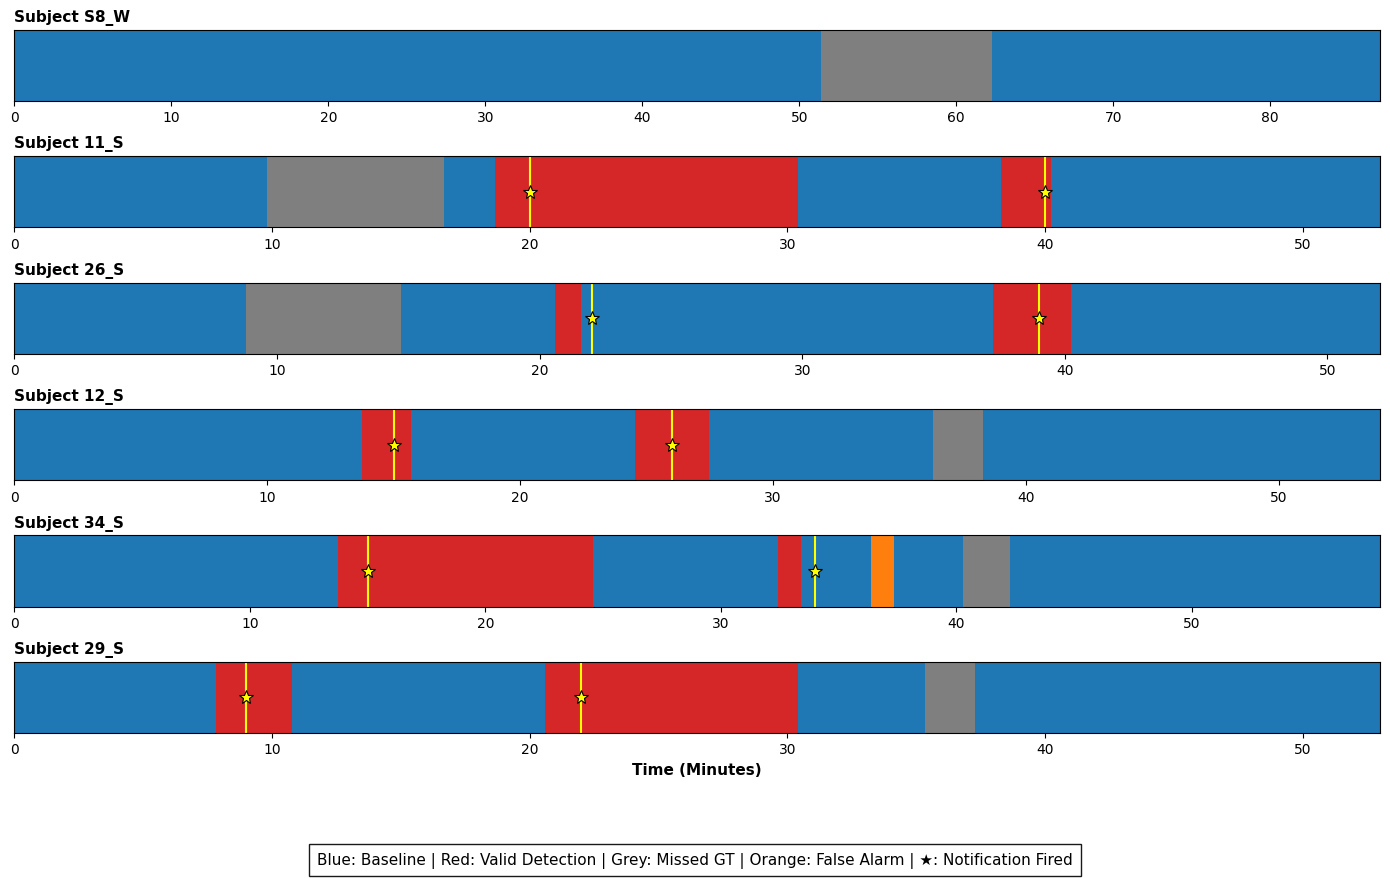

In [5]:
# Compact Deployment Vsiualizer
# ==========================================
# FINAL DEPLOYMENT VISUALIZER (PPT COMPACT)
# Single Figure, Subjects Combined, No GT Row, MAR 0.1 Filter
# UI Fix: Stretched to full width (normalized lengths)
# ==========================================
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- DYNAMIC PATH RESOLUTION ---
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
AI_DIR = os.path.dirname(NOTEBOOK_DIR)
SRC_DIR = os.path.join(AI_DIR, 'src') 
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)
from mamba_model import create_model

DATA_GALAXY = os.path.join(AI_DIR, 'data', 'galaxy', 'Merged')
CKPT_PATH = os.path.join(AI_DIR, 'checkpoints_final', 'wesad_w2.0', 'deployment_master_weights.pt')

TARGET_SUBS = ['S8_W', '11_S', '26_S', '12_S', '34_S', '29_S']
DEVICE = 'cpu'

# HARDWARE MOTION FILTER
MAR_THRESH = 0.10

# DEPLOYMENT CONFIG
CONFIG = {"stride": 60, "conf": 0.60, "dur": 60, "gap": 120, "cd": 5}

GRACE_BEFORE_SEC = 60
GRACE_AFTER_SEC = 120

# Colors: 0: Baseline(Blue), 1: Valid(Red), 2: Missed(Grey), 3: False Alarm(Orange)
COLORS = ['#1f77b4', '#d62728', '#7f7f7f', '#ff7f0e'] 
CMAP = ListedColormap(COLORS)

def get_blocks(binary_array):
    padded = np.concatenate(([0], binary_array, [0]))
    diff = np.diff(padded)
    return list(zip(np.where(diff == 1)[0], np.where(diff == -1)[0]))

def apply_ux_filters(preds, min_dur_chunks, max_gap_chunks):
    merged = preds.copy()
    for z_start, z_end in get_blocks(merged == 0):
        if (z_end - z_start) <= max_gap_chunks and z_start > 0 and z_end < len(merged):
            merged[z_start:z_end] = 1
    final_preds = np.zeros_like(merged)
    for p_start, p_end in get_blocks(merged == 1):
        if (p_end - p_start) >= min_dur_chunks:
            final_preds[p_start:p_end] = 1
    return final_preds

def process_visuals(ux_preds, labels, time_minutes, stride_sec, dur_chunks, cd_chunks):
    gt_blocks = get_blocks(labels == 1)
    pred_blocks = get_blocks(ux_preds == 1)
    
    pred_plot = np.zeros_like(ux_preds)
    notifs_idx = []
    last_notified_end_idx = -9999 
    hit_gt_indices = set()
    
    for ps, pe in pred_blocks:
        cooldown_exp = last_notified_end_idx + cd_chunks
        if pe > cooldown_exp:
            trigger_idx = max(ps + dur_chunks, cooldown_exp)
            if trigger_idx <= pe:
                notifs_idx.append(trigger_idx)
            last_notified_end_idx = pe

        is_block_fa = True
        b_s_sec, b_e_sec = ps * stride_sec, pe * stride_sec
        for s_idx, e_idx in gt_blocks:
            valid_start = (s_idx * stride_sec) - GRACE_BEFORE_SEC
            valid_end = (e_idx * stride_sec) + GRACE_AFTER_SEC
            if max(valid_start, b_s_sec) < min(valid_end, b_e_sec):
                is_block_fa = False
                break
        pred_plot[ps:pe] = 3 if is_block_fa else 1

    for n_idx in notifs_idx:
        notif_sec = n_idx * stride_sec
        for i, (s_idx, e_idx) in enumerate(gt_blocks):
            valid_start = (s_idx * stride_sec) - GRACE_BEFORE_SEC
            valid_end = (e_idx * stride_sec) + GRACE_AFTER_SEC
            if valid_start <= notif_sec <= valid_end:
                hit_gt_indices.add(i)
                break
                
    for i, (s_idx, e_idx) in enumerate(gt_blocks):
        if i not in hit_gt_indices:
            pred_plot[s_idx:e_idx] = 2
            
    return pred_plot, notifs_idx

def main():
    X = np.load(os.path.join(DATA_GALAXY, 'Merged_X_binary.npy'))
    y = np.load(os.path.join(DATA_GALAXY, 'Merged_y_binary.npy'))
    sub = np.load(os.path.join(DATA_GALAXY, 'Merged_sub_binary.npy'), allow_pickle=True)

    model_config = {
        'enc_in': X.shape[1], 'seq_len': X.shape[2], 'num_class': 2, 'projected_space': 64, 
        'd_state': 16, 'dconv': 4, 'e_fact': 2, 'num_mambas': 1, 'patch_len': 50, 
        'dropout': 0.3, 'only_forward_scan': 1, 'reverse_flip': 1, 'max_pooling': 0,
    }
    
    model, _ = create_model(model_config)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True).items()}
    model.load_state_dict(state_dict)
    model.to(DEVICE).eval()

    num_subs = len(TARGET_SUBS)
    # sharex=False is key here to let each row stretch to full width independently
    fig, axes = plt.subplots(num_subs, 1, figsize=(14, 1.4 * num_subs), sharex=False)
    if num_subs == 1:
        axes = [axes]
        
    for i, subject_id in enumerate(TARGET_SUBS):
        ax = axes[i]
        sub_mask = (sub == subject_id)
        if not np.any(sub_mask): 
            ax.set_visible(False)
            continue
            
        idx_step = int(CONFIG['stride'] / 5)
        X_sub = X[sub_mask][::idx_step]
        y_sub = y[sub_mask].argmax(axis=1)[::idx_step]
        
        # Accelerometer magnitude for MAR
        sub_acc_mags = np.mean(X_sub[:, 2, :], axis=1) 
        time_minutes = np.arange(len(y_sub)) * CONFIG['stride'] / 60.0 
        
        with torch.no_grad():
            probs = F.softmax(model(torch.tensor(X_sub, dtype=torch.float32).to(DEVICE)), dim=1).cpu().numpy()
        
        dur_chunks = max(1, int(round(CONFIG['dur'] / CONFIG['stride'])))
        gap_chunks = max(1, int(round(CONFIG['gap'] / CONFIG['stride'])))
        cd_chunks = max(1, int(round((CONFIG['cd'] * 60) / CONFIG['stride'])))
        
        # Apply strict MAR Filtering alongside confidence thresholding
        ux_binary_preds = (probs[:, 1] >= CONFIG['conf']).astype(int)
        ux_binary_preds[sub_acc_mags > MAR_THRESH] = 0 
        
        ux_preds = apply_ux_filters(ux_binary_preds, dur_chunks, gap_chunks)
        plot_res, notifs_idx = process_visuals(ux_preds, y_sub, time_minutes, CONFIG['stride'], dur_chunks, cd_chunks)

        ax.imshow(plot_res[None, :], cmap=CMAP, vmin=0, vmax=3, aspect='auto', extent=[time_minutes[0], time_minutes[-1], 0, 1])
        
        for nt_idx in notifs_idx:
            if nt_idx < len(time_minutes):
                nt_time = time_minutes[nt_idx]
                ax.axvline(x=nt_time, color='yellow', linewidth=1.5)
                ax.plot(nt_time, 0.5, marker='*', markersize=10, color='yellow', markeredgecolor='black', markeredgewidth=0.8)
            
        ax.set_yticks([])
        ax.set_title(f"Subject {subject_id}", fontweight='bold', loc='left', fontsize=11)
        ax.set_xlim(0, time_minutes[-1])
        ax.tick_params(axis='x', labelsize=10)
    
    axes[-1].set_xlabel("Time (Minutes)", fontsize=11, fontweight='bold')
    
    # Legend at the bottom
    fig.text(0.5, -0.04, "Blue: Baseline | Red: Valid Detection | Grey: Missed GT | Orange: False Alarm | ★: Notification Fired", 
             ha='center', va='bottom', fontsize=11, bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', pad=6))
             
    plt.tight_layout(rect=[0, 0.05, 1, 1], h_pad=0.8)
    plt.show()

if __name__ == '__main__':
    main()